# Demo 1a: Text Preprocessing Safari

**Goal:** See how preprocessing choices affect downstream analysis; build a reusable `preprocess(text)` function.
**Text:** Alice in Wonderland, Chapter 1 (~2,000 words).
**Lecture:** Tokenization, Normalization, Stemming and Lemmatization.

## Why This Matters for Health Data

We're practicing on Alice in Wonderland because it's clean, well-known text that lets us focus on learning the mechanics. But every technique here translates directly to clinical NLP:

| Literary Text | Clinical Text | Same Technique |
| ------------- | ------------- | -------------- |
| "didn't" → "did" + "n't" | "500mg" → "500" + "mg" or keep together? | Tokenization choices |
| "Alice" vs "alice" | "MS" (multiple sclerosis) vs "ms" (milliseconds) | Case normalization tradeoffs |
| Remove "the", "and", "is" | Keep "no", "not", "denies" | Stopword list auditing |
| "running" → "run" | "hypertensive" → "hypertension" | Lemmatization for concept grouping |

The pitfalls we'll see—punctuation attached to words, abbreviations split incorrectly, negation words stripped—are exactly what breaks clinical NLP pipelines. Master them on simple text first.

## Setup: all imports and NLTK/spaCy

Run this cell first. All libraries and the spaCy model are loaded here so later cells focus on the analysis. Paths and the spaCy model name come from `config.yaml` so you can point at another data dir or model without editing code.

In [21]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [22]:
from collections import Counter
from pathlib import Path
import string
from typing import Callable

import matplotlib.pyplot as plt
import nltk
import spacy
import yaml
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer

nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

DEMO_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
CONFIG_PATH = DEMO_DIR / "config.yaml"
with open(CONFIG_PATH) as f:
    CONFIG = yaml.safe_load(f)

DATA_DIR = DEMO_DIR / CONFIG["data"]["dir"]
nlp = spacy.load(CONFIG["spacy"]["model"])
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [23]:
# Run `prepare_data.py` if needed

# Check if the data files are present config['data']['files'] in DATA_DIR
for file_name in CONFIG["data"]["files"].values():
    file_path = DATA_DIR / file_name
    if not file_path.exists():
        import prepare_data  # noqa: F401
        prepare_data.main()

## Load Alice excerpt

We load the raw text and inspect its size and the first few lines—this is the *input* our pipeline will transform. The file path comes from `config.yaml` (`data.files.alice`).

In [24]:
alice_path = DATA_DIR / CONFIG["data"]["files"]["alice"]
raw_text = alice_path.read_text(encoding="utf-8")

print(f"Length: {len(raw_text)} chars, ~{len(raw_text.split())} words")
print(raw_text[:500])

Length: 11479 chars, ~2181 words
Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice
“without pictures or conversations?”
So she was considering in her own mind (as well as she could, for the
hot day made her feel very sleepy and stupid), whether the pleasure of
making a daisy-chain would be worth the trouble of getti


## Tokenization: compare methods

**Why it matters:** Different tokenizers treat contractions, punctuation, and hyphenated words differently. Downstream steps (counts, search) depend on these choices.

We use one sentence with edge cases—*didn't*, *rabbit-hole*, punctuation—and compare three methods so you can see exactly how each splits the string.

In [25]:
sentence = "Alice didn't think it so very much out of the way to hear the Rabbit say to itself, 'Oh dear! Oh dear! I shall be late!'"
print("Sample:", sentence)
print()

# Naive split: keeps "didn't" as one token, punctuation attached
print("text.split():", sentence.split())
print()

# NLTK: splits contractions and punctuation
tokens_nltk = nltk.word_tokenize(sentence)
print("nltk.word_tokenize:", tokens_nltk)
print()

# spaCy: one tokenizer per pipeline; tokens have .text
doc = nlp(sentence)
tokens_spacy = [t.text for t in doc]
print("spaCy tokens:", tokens_spacy)

Sample: Alice didn't think it so very much out of the way to hear the Rabbit say to itself, 'Oh dear! Oh dear! I shall be late!'

text.split(): ['Alice', "didn't", 'think', 'it', 'so', 'very', 'much', 'out', 'of', 'the', 'way', 'to', 'hear', 'the', 'Rabbit', 'say', 'to', 'itself,', "'Oh", 'dear!', 'Oh', 'dear!', 'I', 'shall', 'be', "late!'"]

nltk.word_tokenize: ['Alice', 'did', "n't", 'think', 'it', 'so', 'very', 'much', 'out', 'of', 'the', 'way', 'to', 'hear', 'the', 'Rabbit', 'say', 'to', 'itself', ',', "'Oh", 'dear', '!', 'Oh', 'dear', '!', 'I', 'shall', 'be', 'late', '!', "'"]

spaCy tokens: ['Alice', 'did', "n't", 'think', 'it', 'so', 'very', 'much', 'out', 'of', 'the', 'way', 'to', 'hear', 'the', 'Rabbit', 'say', 'to', 'itself', ',', "'", 'Oh', 'dear', '!', 'Oh', 'dear', '!', 'I', 'shall', 'be', 'late', '!', "'"]


All three methods handle "didn't" differently: `split()` keeps it as one token with the comma attached, NLTK splits it into "did" + "n't" (linguistically meaningful), and spaCy also splits contractions but may handle the apostrophe differently. Punctuation like commas and exclamation marks become separate tokens in NLTK and spaCy, but stay attached in `split()`. For downstream tasks like sentiment analysis, how contractions are split matters—"n't" carries negation.

## Sentence tokenization (optional use case)

When you need sentence boundaries (e.g. for sentence-level sentiment or extraction), use `nltk.sent_tokenize`. Word tokenizers don't split on sentence boundaries.

In [26]:
sentences = nltk.sent_tokenize(raw_text[:800])
print(f"First 3 sentences: {len(sentences)} extracted")
for i, s in enumerate(sentences[:3]):
    print(f"  {i+1}. {s[:60]}...")

First 3 sentences: 4 extracted
  1. Alice was beginning to get very tired of sitting by her sist...
  2. There was nothing so _very_ remarkable in that; nor did Alic...
  3. Oh dear!...


## Normalization: lowercase and stopwords

**Why it matters:** Lowercasing collapses "Alice" and "alice" into one type; that helps frequency counts but loses the cue that Alice is a name. Stopword removal shrinks the vocabulary but can remove important negation ("not", "no")—e.g. "No chest pain" in clinical notes. A **common mistake** in clinical NLP is dropping "no"/"not" and reversing meaning.

For some tasks you also remove punctuation (e.g. `string.punctuation`), but keep it when it carries meaning (e.g. hyphens in "COVID-19").

Here we apply lowercase and show how many tokens remain with and without the default English stopword list.

In [27]:
lowered = raw_text.lower()
tokens = nltk.word_tokenize(lowered)
print("Token count (lowercased):", len(tokens))

stop_words = set(stopwords.words("english"))
print("'not' in stopwords?", "not" in stop_words)
print("'no' in stopwords?", "no" in stop_words)

tokens_no_stop = [t for t in tokens if t not in stop_words]
print("After removing stopwords:", len(tokens_no_stop))

Token count (lowercased): 2635
'not' in stopwords? True
'no' in stopwords? True
After removing stopwords: 1431


## Stem vs Lemma

**Why it matters:** Stemming uses rules and can produce non-words ("studies" → "studi"); lemmatization uses a dictionary and needs part-of-speech for words like "better" → "good". Both reduce surface forms to a single base so we can count variants together.

We run stemmer and lemmatizer on a few example words so you can see the tradeoff.

In [28]:
words = ["curiouser", "running", "studies", "better"]
for w in words:
    stem = stemmer.stem(w)
    lemma_n = lemmatizer.lemmatize(w, pos="n")
    lemma_a = lemmatizer.lemmatize(w, pos="a")
    print(f"  {w}: stem={stem}, lemma(n)={lemma_n}, lemma(a)={lemma_a}")

  curiouser: stem=curious, lemma(n)=curiouser, lemma(a)=curious
  running: stem=run, lemma(n)=running, lemma(a)=running
  studies: stem=studi, lemma(n)=study, lemma(a)=studies
  better: stem=better, lemma(n)=better, lemma(a)=good


## Build a preprocess function

We combine tokenization, optional lowercase/stopword removal, and lemmatization into one reusable function. Later we'll use its output for a visual summary of the vocabulary.

In [29]:
def preprocess(
    text: str,
    *,
    lowercase: bool = True,
    remove_stop: bool = True,
    lemmatize: bool = True,
    stop_words: set | None = None,
    punctuation: bool = True,
    tokenizer: Callable[[str], list[str]] | None = None,
) -> list[str]:
    if stop_words is None and remove_stop:
        stop_words = set(stopwords.words("english"))
    if lowercase:
        text = text.lower()
    if punctuation:
        remove_punctuation = set(string.punctuation)
        text = "".join(ch for ch in text if ch not in remove_punctuation)
    # Use custom tokenizer if provided, otherwise default to nltk.word_tokenize
    if tokenizer is not None:
        tokens = tokenizer(text)
    else:
        tokens = nltk.word_tokenize(text)
    if remove_stop and stop_words:
        tokens = [t for t in tokens if t not in stop_words]
    if not lemmatize:
        return tokens
    out = []
    for t in tokens:
        lemma = lemmatizer.lemmatize(t, pos="v")
        if lemma == t:
            lemma = lemmatizer.lemmatize(t, pos="n")
        if lemma == t:
            lemma = lemmatizer.lemmatize(t, pos="a")
        out.append(lemma)
    return out

first_para = raw_text.split("\n\n")[0]
print("First paragraph tokens (preprocessed):", preprocess(first_para)[:25])

First paragraph tokens (preprocessed): ['alice', 'begin', 'get', 'tire', 'sit', 'sister', 'bank', 'nothing', 'twice', 'peep', 'book', 'sister', 'read', 'picture', 'conversation', '“', 'use', 'book', '”', 'think', 'alice', '“', 'without', 'picture', 'conversation']


## Visual: top tokens after preprocessing

Seeing the most frequent tokens as a bar chart makes the effect of preprocessing concrete: common words dominate, and the shape of the distribution reflects our choices (e.g. no stopwords, lemmatized). We use `Counter` from Python's `collections` module to count token frequencies—`Counter(tokens).most_common(n)` returns the n most frequent items as (token, count) pairs. The number of top terms is set in `config.yaml` (`visualization.top_tokens`).

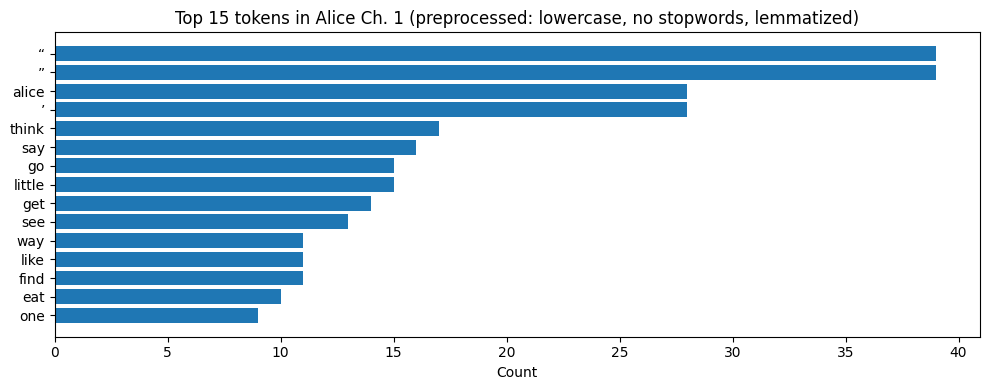

In [30]:
tokens = preprocess(raw_text)
counts = Counter(tokens)
top_n = CONFIG["visualization"]["top_tokens"]
top = counts.most_common(top_n)
terms, freqs = zip(*top)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(range(len(terms)), freqs, align="center")
ax.set_yticks(range(len(terms)))
ax.set_yticklabels(terms)
ax.invert_yaxis()
ax.set_xlabel("Count")
ax.set_title(f"Top {top_n} tokens in Alice Ch. 1 (preprocessed: lowercase, no stopwords, lemmatized)")
plt.tight_layout()
plt.show()

## Text statistics from preprocessing

Beyond word frequencies, preprocessing lets us compute text complexity metrics. These are useful for comparing writing styles, assessing readability, and characterizing documents.

- **Vocabulary richness** (type-token ratio): unique words / total words. Higher = more diverse vocabulary.
- **Average sentence length**: words per sentence. Longer = more complex syntax.
- **Average word length**: characters per word. Longer = more formal/technical vocabulary.

In [31]:
# Compute text statistics
sentences = nltk.sent_tokenize(raw_text)
tokens_raw = nltk.word_tokenize(raw_text.lower())
words_only = [t for t in tokens_raw if t.isalpha()]

vocab_richness = len(set(words_only)) / len(words_only)
avg_sentence_len = len(words_only) / len(sentences)
avg_word_len = sum(len(w) for w in words_only) / len(words_only)

print(f"Vocabulary richness (type-token ratio): {vocab_richness:.3f}")
print(f"Average sentence length: {avg_sentence_len:.1f} words")
print(f"Average word length: {avg_word_len:.1f} characters")

Vocabulary richness (type-token ratio): 0.275
Average sentence length: 34.4 words
Average word length: 3.9 characters


Alice in Wonderland, written in 1865, shows characteristics of Victorian literary prose: moderate vocabulary richness (Lewis Carroll's whimsical style uses varied but accessible words), relatively long sentences (complex syntax was common), and standard word lengths. Compare these numbers to modern text—tweets average ~10 words per sentence; clinical notes vary widely depending on author and note type.

## Alternative: RegexpTokenizer

Instead of removing punctuation before tokenization, we can use `RegexpTokenizer` to handle it during tokenization. This approach is useful when you want a single regex pattern to define what counts as a token.

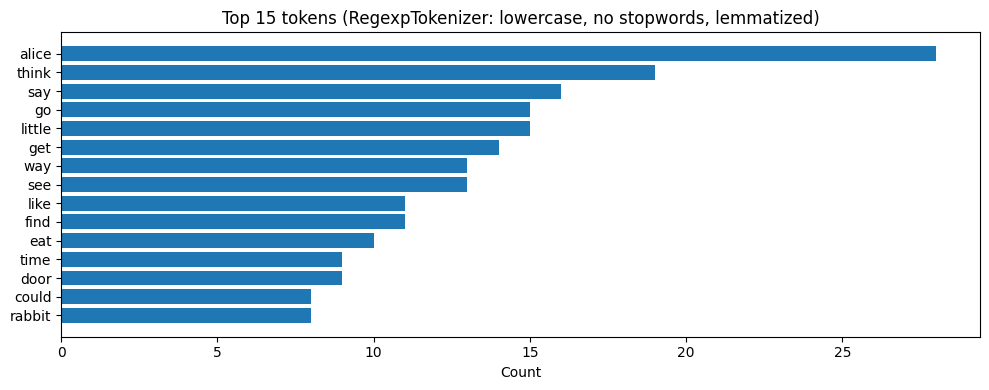

In [32]:
# Alternative: use RegexpTokenizer to handle punctuation during tokenization
# This approach removes punctuation as part of tokenization rather than pre-filtering

# Define a regex pattern that matches only word characters (\w+)
# This automatically ignores punctuation and extra whitespace
regex_tokenizer = RegexpTokenizer(r'\w+')

# Use preprocess with our custom tokenizer and punctuation=False
# (since RegexpTokenizer already handles punctuation removal)
tokens = preprocess(raw_text, tokenizer=regex_tokenizer.tokenize, punctuation=False)
counts = Counter(tokens)
top_n = CONFIG["visualization"]["top_tokens"]
top = counts.most_common(top_n)
terms, freqs = zip(*top)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(range(len(terms)), freqs, align="center")
ax.set_yticks(range(len(terms)))
ax.set_yticklabels(terms)
ax.invert_yaxis()
ax.set_xlabel("Count")
ax.set_title(f"Top {top_n} tokens (RegexpTokenizer: lowercase, no stopwords, lemmatized)")
plt.tight_layout()
plt.show()

## Clinical Text

Apply what you learned to clinical examples. Notice how the same techniques reveal different challenges.

**Tokenization challenges in clinical notes:**

In [33]:
# Clinical text has unique tokenization challenges
clinical_samples = [
    "Pt c/o SOB x 3 days",           # abbreviations, "x" means "for"
    "BP 120/80, HR 72, T 98.6°F",    # vitals with units and symbols
    "500mg metformin b.i.d.",        # dosage + frequency abbreviations
    "COVID-19 positive, r/o pneumonia",  # hyphenated terms, abbreviations
]

for sample in clinical_samples:
    print(f"Original: {sample}")
    print(f"  split():         {sample.split()}")
    print(f"  word_tokenize(): {nltk.word_tokenize(sample)}")
    print()

Original: Pt c/o SOB x 3 days
  split():         ['Pt', 'c/o', 'SOB', 'x', '3', 'days']
  word_tokenize(): ['Pt', 'c/o', 'SOB', 'x', '3', 'days']

Original: BP 120/80, HR 72, T 98.6°F
  split():         ['BP', '120/80,', 'HR', '72,', 'T', '98.6°F']
  word_tokenize(): ['BP', '120/80', ',', 'HR', '72', ',', 'T', '98.6°F']

Original: 500mg metformin b.i.d.
  split():         ['500mg', 'metformin', 'b.i.d.']
  word_tokenize(): ['500mg', 'metformin', 'b.i.d', '.']

Original: COVID-19 positive, r/o pneumonia
  split():         ['COVID-19', 'positive,', 'r/o', 'pneumonia']
  word_tokenize(): ['COVID-19', 'positive', ',', 'r/o', 'pneumonia']



Notice how `word_tokenize` splits "120/80" (you might want to keep BP as one token), handles "°F" separately, and splits "COVID-19". For clinical NLP, you often need custom tokenization rules or post-processing.

**Stopwords and negation—a clinical pitfall:**

In [34]:
# The standard stopword list includes negation words
stop_words = set(stopwords.words("english"))
clinical_note = "Patient denies chest pain. No fever. Not taking medications."

# Dangerous: removing all stopwords loses critical meaning
tokens = nltk.word_tokenize(clinical_note.lower())
filtered_dangerous = [t for t in tokens if t not in stop_words]
print("With standard stopwords:", filtered_dangerous)
# Lost: "no", "not" — now "chest pain" looks affirmed!

# Safer: preserve negation words
safe_stop_words = stop_words - {"no", "not", "nor", "neither", "never", "none"}
filtered_safe = [t for t in tokens if t not in safe_stop_words]
print("Preserving negation:   ", filtered_safe)

With standard stopwords: ['patient', 'denies', 'chest', 'pain', '.', 'fever', '.', 'taking', 'medications', '.']
Preserving negation:    ['patient', 'denies', 'chest', 'pain', '.', 'no', 'fever', '.', 'not', 'taking', 'medications', '.']


In clinical NLP, "denies chest pain" and "reports chest pain" have opposite meanings. Always audit your stopword list for negation terms.

**Lemmatization for medical vocabulary:**

In [35]:
# Medical terms benefit from lemmatization the same way literary text does
medical_words = ["hypertensive", "hypertension", "diabetic", "diabetes", "metastases", "metastasis"]
for w in medical_words:
    lemma = lemmatizer.lemmatize(w, pos="n")
    if lemma == w:
        lemma = lemmatizer.lemmatize(w, pos="a")
    print(f"  {w:15} → {lemma}")

  hypertensive    → hypertensive
  hypertension    → hypertension
  diabetic        → diabetic
  diabetes        → diabetes
  metastases      → metastasis
  metastasis      → metastasis


Standard lemmatizers work for common medical terms, but may struggle with highly specialized vocabulary. For production clinical NLP, consider domain-specific tools like scispaCy (covered in Demo 3).